In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
## Load Dataset

In [5]:
df = pd.read_csv("Student_data.csv")

df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [ ]:
# Dataset description 
This dataset consists of 500 students with their study habits, demographics and exam results. 

In [6]:
## Data Wrangling

In [7]:
def wrangle(filepath):

    # Load dataset
    df = pd.read_csv(filepath)

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Remove missing values
    df = df.dropna()

    # Drop unnecessary column
    df = df.drop(columns=["student_id"])

    return df

In [8]:
df = wrangle("student_data.csv")

df.head()

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,Female,19,10,90.5,High School,Yes,No,73,49,No
3,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [9]:
## Exploratory Data Analysis

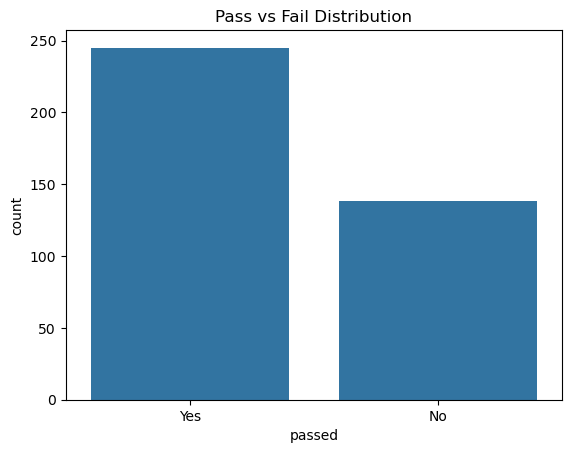

In [10]:
sns.countplot(x="passed", data=df)

plt.title("Pass vs Fail Distribution")

plt.show()

In [11]:
### Study Hours and Passing

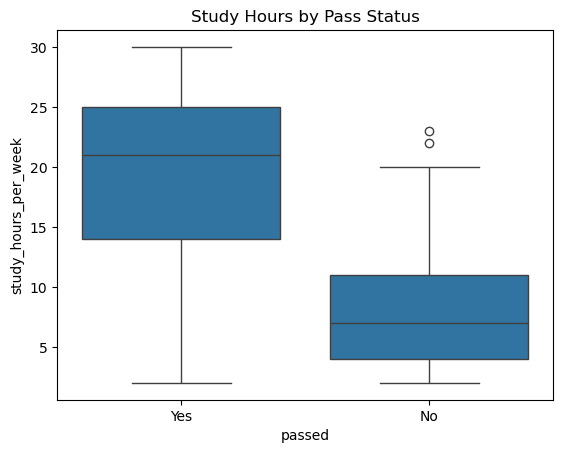

In [12]:
sns.boxplot(x="passed", y="study_hours_per_week", data=df)

plt.title("Study Hours by Pass Status")

plt.show()

In [ ]:
### Attendance Rate and Passing

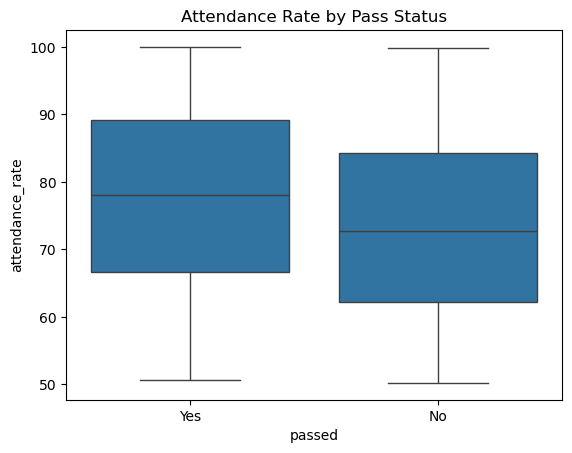

In [13]:
sns.boxplot(x="passed", y="attendance_rate", data=df)

plt.title("Attendance Rate by Pass Status")

plt.show()

In [ ]:
### Previous Scores and Passing

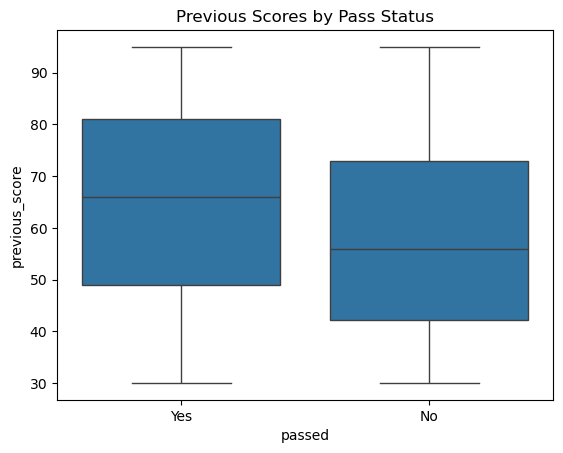

In [14]:
sns.boxplot(x="passed", y="previous_score", data=df)

plt.title("Previous Scores by Pass Status")

plt.show()

In [ ]:
### Gender and Passing

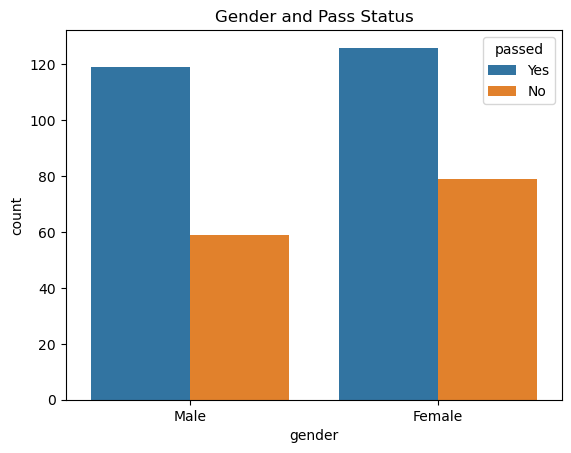

In [15]:
sns.countplot(x="gender", hue="passed", data=df)

plt.title("Gender and Pass Status")

plt.show()

In [ ]:
### Observation

Students who passed appear to have studied far more hours compared to those that did not. Additionally, we see that female students, overall, had higher pass rates compared to male studets.

In [ ]:
# Data Preprocessing

In [16]:
df["passed"] = df["passed"].map({"Yes": 1, "No": 0})

In [17]:
categorical_cols = [
    "gender",
    "parent_education",
    "internet_access",
    "extracurricular"
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
## Features and Target Variable
X = df.drop("passed", axis=1)

# Remove final_score to avoid leakage
X = X.drop("final_score", axis=1)

y = df["passed"]

In [ ]:
## Avoiding Data Leakage

I removed the variable `final_score` because it directly determines whether a student passed. Including this variable would create data leakage and artificially increase model performance.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Baseline Model

baseline = y_train.mode()[0]

baseline_preds = [baseline] * len(y_test)

baseline_acc = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.6883116883116883


In [21]:
# Logistic Regression Model 

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
# Predictions 

y_pred = model.predict(X_test)

In [23]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8441558441558441


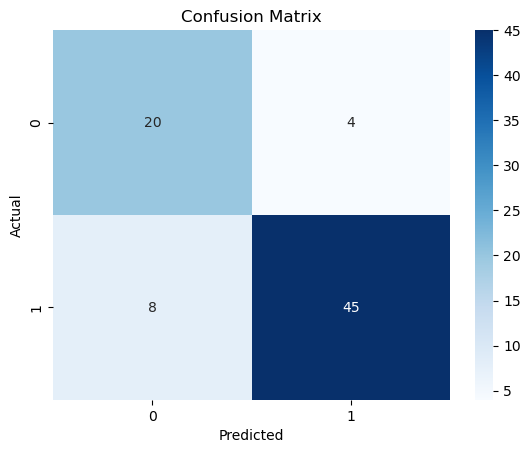

In [24]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Observation regarding confusion Matrix:
The number of false positives and false negatives is relatively low, indicating that the logistic regression model performed well in correctly classifying students who passed and failed. This suggests that the model has strong predictive accuracy overall. This is an important diagnostic to check for when evaluating a model.

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.83      0.77        24
           1       0.92      0.85      0.88        53

    accuracy                           0.84        77
   macro avg       0.82      0.84      0.83        77
weighted avg       0.85      0.84      0.85        77



In [26]:
# Conclusion

The logistic regression model was able to predict student pass/fail outcomes with strong accuracy. Variables such as attendance rate, study hours, and previous academic performance appeared to be important predictors of student success.

The final model performed better than the baseline model, suggesting that the selected variables provide useful predictive information.

SyntaxError: invalid syntax (2972389595.py, line 3)